# Projections and orthogonalisations Code Challenges and Solutions to Practice Questions

## Code Challenge 1: Eigenvalues of diagonal and triangular matrices

- Generate a diagonal matrix (2x2), compute its eigenvalues
- Then expand to larger diagonal matrix
- Generate some triangular matrices (lower and upper), computs their eigenvalues
- See any patterns that emerge from these matrices' eigevalues

In [1]:
import numpy as np

# Set matrix size
n = 3

# Generate random matrix
A = np.random.randn(n, n)
# Diagonalise
A = np.diag(np.diag(A))
print("Diagonal matrix A:\n", A)

# Find eigenvalues
eigvalsA = np.linalg.eig(A)
print("Eigenvalues of A:\n", eigvalsA[0])

# So, eigenvalues of a diagonal matrix are the diagonal elements

Diagonal matrix A:
 [[ 0.69438946  0.          0.        ]
 [ 0.         -0.56019859  0.        ]
 [ 0.          0.         -1.01528898]]
Eigenvalues of A:
 [ 0.69438946 -0.56019859 -1.01528898]


In [ ]:
import numpy as np

# Set matrix size
n = 3

# Generate random matrix
A = np.random.randn(n, n)

# Turn into upper triangular matrix
UT = np.triu(A)
print("Upper triangular matrix UT:\n", UT)
# Find eigenvalues of UT
eigvalsUT = np.linalg.eig(UT)
print("Eigenvalues of UT:\n", eigvalsUT[0])

# Turn into lower triangular matrix
LT = np.tril(A)
print("Lower triangular matrix LT:\n", LT)
# Find eigenvalues of LT
eigvalsLT = np.linalg.eig(LT)
print("Eigenvalues of UT:\n", eigvalsLT[0])

# So, eigenvalues of a upper or lower triangular matrix are also the diagonal elements

Upper triangular matrix UT:
 [[-0.41520148 -0.06044555  1.12014535]
 [ 0.          1.20424484 -0.89715592]
 [ 0.          0.          1.67094994]]
Eigenvalues of UT:
 [-0.41520148  1.20424484  1.67094994]
Lower triangular matrix LT:
 [[-0.41520148  0.          0.        ]
 [ 0.27313831  1.20424484  0.        ]
 [ 1.28593275 -1.82849005  1.67094994]]
Eigenvalues of UT:
 [ 1.67094994  1.20424484 -0.41520148]


## Code Challenge 2: Eigenvalues of random matrices

- Generate a large (40x40) random matrix
- Extract their eigenvalues
- Make a plot

- Repeat this lots of time for lots of random matrices, put all the eigenvalues on the same plot.

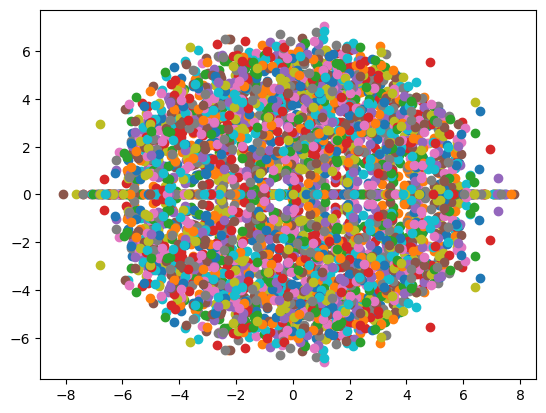

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# Set matrix size
n = 40

for i in range(100):

    # Generate random matrix
    A = np.random.randn(n, n)

    # Calculate the eigenvalues
    eigenvalsA = np.linalg.eig(A)

    # Plot
    plt.scatter(eigenvalsA[0].real, eigenvalsA[0].imag)

In [79]:
A = np.array([[1, 2, 3], [4, 3, 7], [3, 3, 6]])
print(np.shape(A))

np.linalg.eig(A)

print(np.round(np.linalg.eig(A)[0], 2))

(3, 3)
[11. -1. -0.]


## Code Challenge 3: Eigendecomposition of matrix differences

- Generate a random matrices A and B (make them symmetric)
- Calculate $(A-B)v = \lambda v$
- Calculate $(A^2-AB-BA+B^2)v = \lambda^2 v$
- Test whether the eigenvectors of each are equal
- Test whether the squared eigenvalues of $(A-B)v = (A^2-AB-BA+B^2)v$


In [11]:
import numpy as np

# Set matrix size
n = 5

# Generate random matrix
A = np.random.randn(n, n)
B = np.random.randn(n, n)

# Make symmetric
A = A.T @ A
B = B.T @ B

# Generate eig vals of A-B and A^2-AB-BA+B^2
A_eigval, A_eigvec = np.linalg.eig(A - B)
B_eigval, B_eigvec = np.linalg.eig(A @ A - A @ B - B @ A + B @ B)

sortidxA = np.argsort(np.abs(A_eigval))
sortidxB = np.argsort(B_eigval)

sorted_A_eigval = A_eigval[sortidxA]
sorted_B_eigval = B_eigval[sortidxB]
sorted_A_eigvec = A_eigvec[:, sortidxA]
sorted_B_eigvec = B_eigvec[:, sortidxB]

# Compare
print("Squared Eigenvalues of (A-B)v:\n", sorted_A_eigval**2)
print("Eigenvalues of (A^2-AB-BA+B^2)v:\n", sorted_B_eigval)
print()
print("Eigenvectors of (A-B)v:\n", sorted_A_eigvec)
print("Eigenvectors of (A^2-AB-BA+B^2)v:\n", sorted_B_eigvec)

Squared Eigenvalues of (A-B)v:
 [ 0.29028225  3.1963691  14.96079446 54.34244926 66.52724952]
Eigenvalues of (A^2-AB-BA+B^2)v:
 [ 0.29028225  3.1963691  14.96079446 54.34244926 66.52724952]

Eigenvectors of (A-B)v:
 [[ 0.41032004  0.29572602  0.2052377  -0.73577144 -0.40087588]
 [-0.79486027 -0.02191669 -0.06621489 -0.57280719  0.18768141]
 [ 0.14680324 -0.85562644  0.44767082 -0.19059036  0.09807321]
 [ 0.3266784  -0.29215502 -0.82932865 -0.27879053  0.20595266]
 [-0.26751569 -0.30759489 -0.25553455  0.12838796 -0.86720203]]
Eigenvectors of (A^2-AB-BA+B^2)v:
 [[ 0.41032004 -0.29572602  0.2052377  -0.73577144 -0.40087588]
 [-0.79486027  0.02191669 -0.06621489 -0.57280719  0.18768141]
 [ 0.14680324  0.85562644  0.44767082 -0.19059036  0.09807321]
 [ 0.3266784   0.29215502 -0.82932865 -0.27879053  0.20595266]
 [-0.26751569  0.30759489 -0.25553455  0.12838796 -0.86720203]]


## Code Challenge 4: Reconstruct a matrix using eigenlayers
- Create an 5 x 5 symmetrix matrix
- Take its eigendecomp
- Find the norm of the outer product $v_i$ with itself
- Create 1 layer of the original matrix as $\lambda vv^T$, compute its norm
- Reconstruct original matrix by summing over its eigenlayers (outer products)


In [61]:
import numpy as np

# Set matrix size
n = 5

# Generate random matrix
A = np.random.randn(n, n)
# Make symmetric
A = A.T @ A

print("Original matrix A:\n", A)

# Eigendecomposition
D, V = np.linalg.eig(A)
print("Eigenvalues:\n", D)
print("Eigenvectors:\n", V)

# Copy eigenvector v_0
v_i = np.copy(V[:, 0])
print("Eigenvector v_0:\n", v_i)

# Calculate the norm of the outer product of v_i with itself (should be 1)
norm_v_i = np.linalg.norm(np.linalg.outer(v_i, v_i.T))
print("Norm V_0 =", np.round(norm_v_i, 3))

# Calculate layer 1 of A using the first eigenvalue and the first eigenvector
A_layer1 = D[0] * np.linalg.outer(v_i, v_i.T)
print("Layer 1 of A:\n", A_layer1)

# Calculate the norm of A_layer1 (should be the same as the first eigenvalue)
norm_A_layer1 = np.linalg.norm(A_layer1)
print("Norm of Layer 1 =", norm_A_layer1)

Original matrix A:
 [[ 4.72129231  6.34682826  0.97735733  4.25439642  0.05715775]
 [ 6.34682826 11.73073375  2.10174121  6.10390265  1.50754057]
 [ 0.97735733  2.10174121  0.98903647  1.01566398 -0.21356032]
 [ 4.25439642  6.10390265  1.01566398  8.28630462  2.10407822]
 [ 0.05715775  1.50754057 -0.21356032  2.10407822  2.96635117]]
Eigenvalues:
 [20.71921547  4.42743909  2.50322587  0.18497033  0.85886755]
Eigenvectors:
 [[-0.4304974  -0.23925036 -0.33004904 -0.54701278  0.59099569]
 [-0.71151477 -0.41692336  0.41716433  0.36334645 -0.11779186]
 [-0.12294148 -0.15946891 -0.0375949  -0.62481643 -0.75342293]
 [-0.52745981  0.66780939 -0.45124031  0.18981803 -0.19017903]
 [-0.12284243  0.5454672   0.71554899 -0.37726638  0.18175531]]
Eigenvector v_0:
 [-0.4304974  -0.71151477 -0.12294148 -0.52745981 -0.12284243]
Norm V_0 = 1.0
Layer 1 of A:
 [[ 3.839851    6.34640466  1.09658492  4.70471385  1.09570142]
 [ 6.34640466 10.48917056  1.81240669  7.7758272   1.81094647]
 [ 1.09658492  1.8124

In [ ]:
# Build up A based on D_i * v_i @ v_i.T

# Initialize A_reconstructed as a zero matrix
A_reconstructed = np.zeros([n, n])

# Loop through each eigenvalue and eigenvector, and add the contribution to A_reconstructed
# This is identical to V @ np.diag(D) @ V.T, the
for i in range(n):
    A_reconstructed += D[i] * np.linalg.outer(V[:, i], V[:, i].T)
print("Original matrix A:\n", A)
print("Reconstructed matrix A:\n", A_reconstructed)

Original matrix A:
 [[ 4.72129231  6.34682826  0.97735733  4.25439642  0.05715775]
 [ 6.34682826 11.73073375  2.10174121  6.10390265  1.50754057]
 [ 0.97735733  2.10174121  0.98903647  1.01566398 -0.21356032]
 [ 4.25439642  6.10390265  1.01566398  8.28630462  2.10407822]
 [ 0.05715775  1.50754057 -0.21356032  2.10407822  2.96635117]]
Reconstructed matrix A:
 [[ 4.72129231  6.34682826  0.97735733  4.25439642  0.05715775]
 [ 6.34682826 11.73073375  2.10174121  6.10390265  1.50754057]
 [ 0.97735733  2.10174121  0.98903647  1.01566398 -0.21356032]
 [ 4.25439642  6.10390265  1.01566398  8.28630462  2.10407822]
 [ 0.05715775  1.50754057 -0.21356032  2.10407822  2.96635117]]


## Code Challenge 5: trace and determinant, eigenvalues sum and product
- Random matrix A
- Compare trace(A) with sum(eigenvalues)
- Compare det(A) with sum(eigenvalues)
- Repeat with reduced rank matrix


In [80]:
import numpy as np

# Set matrix size
n = 5

# Generate random matrix
A = np.random.randn(n, n)
# Make symmetric for real eigenvalues
A = A.T @ A

# Calculate the trace of A
trace_A = np.trace(A)
print("Trace of A:\n", trace_A)

# Calculate the sum of the eigenvalues of A
D = np.linalg.eig(A)[0]
print("Sum of eigenvalues of A:\n", np.sum(D))

# Calculate the determinant of A
det_A = np.linalg.det(A)
print("\nDeterminant of A:\n", det_A)
# Calculate the product of the eigenvalues of A
D = np.linalg.eig(A)[0]
print("Product of eigenvalues of A:\n", np.prod(D))


# Reduce rank of matrix A
A_red = np.random.randn(n, n)
A_red[0] = A_red[1]
A_red = A_red.T @ A_red

# Calculate the trace of A_red
trace_A_red = np.trace(A_red)
print("\nTrace of reduced rank A:\n", trace_A_red)

# Calculate the sum of the eigenvalues of A_red
D_red = np.linalg.eig(A_red)[0]
print("Sum of eigenvalues of reduced rank A:\n", np.sum(D_red))

# Calculate the determinant of A_red
det_A_red = np.linalg.det(A_red)
print("\nDeterminant of reduced rank A:\n", np.round(det_A_red, 3))

# Calculate the product of the eigenvalues of A_red
D_red = np.linalg.eig(A_red)[0]
print("Product of eigenvalues of reduced rank A:\n", np.round(np.prod(D_red), 3))

Trace of A:
 15.766997560163361
Sum of eigenvalues of A:
 15.766997560163365

Determinant of A:
 0.9755945353529925
Product of eigenvalues of A:
 0.9755945353529919

Trace of reduced rank A:
 20.739420882813615
Sum of eigenvalues of reduced rank A:
 20.739420882813604

Determinant of reduced rank A:
 0.0
Product of eigenvalues of reduced rank A:
 0.0


## Code Challenge 6: General eigen decomposition (GED) in large and small matrices
- Goal: compare eig($S, R$) with eig($R^{-1}S$)
- First: on 2x2 matrix
- Then: on real data (real_matrices.mat)


Eigenvalues of eig(S, R):
 [ 0.70171907+0.j -7.1017763 +0.j]

Eigenvalues of eig(R^-1 @ S):
 [ 0.70171907+0.j -7.1017763 +0.j]


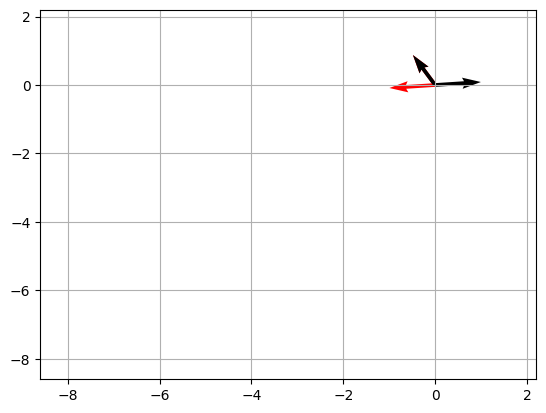

In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt


# On the 2x2 matrix
n = 2

# Generate two random matrices
S = np.random.randn(n, n)
R = np.random.randn(n, n)

# Calculate eig(S,R)
eigval_SR, eigvec_SR = scipy.linalg.eig(S, R)
print("Eigenvalues of eig(S, R):\n", eigval_SR)

# Calculate eig(R^-1@S)
eigval_RinvS, eigvec_RinvS = scipy.linalg.eig(np.linalg.inv(R) @ S)
print("\nEigenvalues of eig(R^-1 @ S):\n", eigval_SR)

plt.quiver(
    0,
    0,
    eigvec_SR[0, 0],
    eigvec_SR[1, 0],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="r",
)
plt.quiver(
    0,
    0,
    eigvec_SR[0, 1],
    eigvec_SR[1, 1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="r",
)
plt.quiver(
    0,
    0,
    eigvec_RinvS[0, 0],
    eigvec_RinvS[1, 0],
    angles="xy",
    scale_units="xy",
    scale=1,
)
plt.quiver(
    0,
    0,
    eigvec_RinvS[0, 1],
    eigvec_RinvS[1, 1],
    angles="xy",
    scale_units="xy",
    scale=1,
)
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.grid()

Eigenvalues of eig(S, R) from data:
 [0.87592661 0.88607613 0.91864374 0.97278377 1.00358319 1.01202988
 1.02992102 1.04931948 1.08814759 1.16413972 1.19803654 1.2025481
 1.21832991 1.52685047 1.70330697 2.43167856]

Eigenvalues of eig(R^-1 @ S) from data:
 [-4048620.95016496 -1469454.64894224  -496274.86489334  -316388.8228484
  -267618.61338774   -58332.41006099   -49829.70710378    12424.16269934
    24314.17200427    42287.73895073    46323.80682409   109644.93922992
   211700.91982905   538380.85074923  1622268.57308308  4099193.28100693]


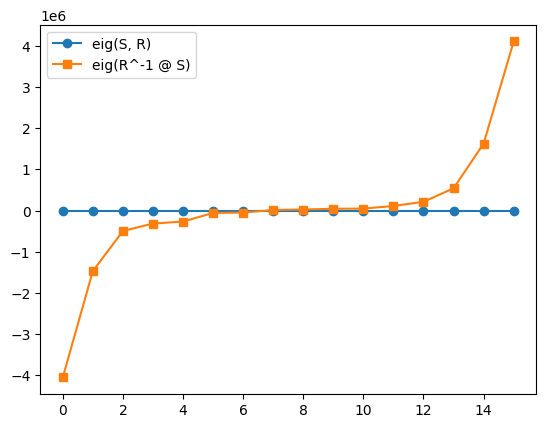

In [187]:
import numpy as np
import scipy
import scipy.io
import matplotlib.pyplot as plt

# Import data
data = scipy.io.loadmat("real_matrices.mat")

# Calculate eigh(S,R) from data
eigval_SR, eigvec_SR = scipy.linalg.eigh(data["S"], data["R"])
print("Eigenvalues of eig(S, R) from data:\n", eigval_SR)

# Calculate eigh(R^-1@S) from data
eigval_RinvS, eigvec_RinvS = scipy.linalg.eigh(np.linalg.inv(data["R"]) @ data["S"])
print("\nEigenvalues of eig(R^-1 @ S) from data:\n", eigval_RinvS)

# Note: using eigh instead of eig gives us real eigenvalues, which is what we expect for this data
# This can only be done for symmetric matrices, which is the case for S and R in this data

# Plot eigenvalues
plt.plot(eigval_SR, "-o", label="eig(S, R)")
plt.plot(eigval_RinvS, "-s", label="eig(R^-1 @ S)")
plt.legend()